# <span style="color:rgb(213,80,0)">Exploring interactively the impact of the P2D parameters on EIS output</span>

We load the raw BattMo JSON parameter files for chemistry (Chen2020) and geometry.


In [1]:
jsonstruct_material = parseBattmoJson(fullfile('ParameterData','ParameterSets','Chen2020','chen2020_lithium_ion_battery.json'));
jsonstruct_geometry = parseBattmoJson(fullfile('Examples', 'JsonDataFiles', 'geometryChen.json'));


Merging the chemistry and geometry JSON structures into a unified configuration.


In [2]:
jsonstruct = mergeStructs({jsonstruct_material, jsonstruct_geometry});


Enabling and configuring the double layer capacitance on the negative electrode interface. By default, the raw Chen2020 dataset does not enable the double\-layer capacitance. We must set useDoubleLayerCapacity to true so the solver registers the parameter.


In [3]:
ne  = 'NegativeElectrode';
co  = 'Coating';
am  = 'ActiveMaterial';
itf = 'Interface';


includeDoubleLayer = true;


if includeDoubleLayer
    jsonstruct.(ne).(co).(am).(itf).useDoubleLayerCapacity = true;
    jsonstruct.(ne).(co).(am).(itf).doubleLayerCapacitance = 0.2; % F/m^2
end


Instantiating the Impedance Explorer application handle with our custom JSON structure.


In [4]:
impexp = ImpedanceExplorer(jsonstruct);


Cleaning up the MATLAB workspace by closing any previously opened UI figures.


In [5]:
erase_previous_figure = true;
if erase_previous_figure
    delete(findall(0, 'Type', 'Figure'));
end


We can dynamically override the parameters. Here, as an example, we change the first parameter.


In [6]:
change_a_parameter = true;
if change_a_parameter
    impexp.parameters{1} = {'PositiveElectrode', 'Coating', 'ActiveMaterial', 'Interface', 'volumetricSurfaceArea'};
end


Launching the interactive graphical user interface.



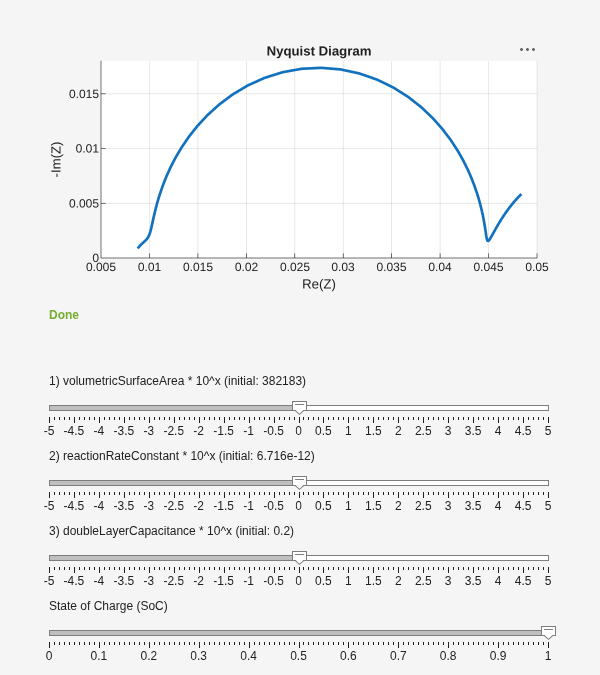

In [7]:
impexp.start();